# Problem Statement

Sales teams often lack a clear, data-driven understanding of regional performance, making it difficult to identify growth opportunities and optimize resources. This project aims to analyze and visualize regional sales data to uncover trends, evaluate profitability, and support strategic decision-making.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Regional_Sales.xlsx', sheet_name = None)


In [3]:
df_sales = df['Sales Orders']
df_customers = df['Customers']
df_products = df['Products']
df_regions = df['Regions']
df_state_reg = df['State Regions']
df_budgets = df['2017 Budgets']

In [4]:
print("df_sales shape: ",(df_sales.shape))
print("df_customers: ",(df_customers.shape))
print("df_products shape: ",(df_products.shape))
print("df_regions shape: ",(df_regions.shape))
print("df_state_reg shape: ",(df_state_reg.shape))
print("df_budgets shape: ",(df_budgets.shape))

df_sales shape:  (64104, 12)
df_customers:  (175, 2)
df_products shape:  (30, 2)
df_regions shape:  (994, 15)
df_state_reg shape:  (49, 3)
df_budgets shape:  (30, 2)


In [5]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [6]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [7]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [8]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [9]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [10]:
df_state_reg.columns = df_state_reg.iloc[0]
df_state_reg = df_state_reg[1:].reset_index(drop=True)
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [11]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [12]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [13]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [14]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [15]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [16]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [17]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [18]:
# Merge Orders With Customers
df1 = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [19]:
# Merge Orders With Products
df1 = df1.merge(
    df_products,
    how = 'left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [20]:
# Merge Orders With Regions
df1 = df1.merge(
    df_regions,
    how = 'left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [21]:
# Merge Orders With State Region
df1 = df1.merge(
    df_state_reg[['State Code','Region']],
    how = 'left',
    left_on = 'state_code',
    right_on = 'State Code'
)
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [22]:
#Merge Orders With Budget
df1 = df1.merge(
    df_budgets,
    how = 'left',
    on = 'Product Name',
)
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [23]:
df1.to_csv('DA1.csv')

In [23]:
#Remove Duplicates Columns
cols_to_drop = ['Customer Index','Index','id','State Code']
df1 = df1.drop(columns = cols_to_drop,errors='ignore')
df1.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [24]:
#Convert Coluomns Name to Lower Case
df1.columns = df1.columns.str.lower()
df1.head()

,ordernumber,orderdate,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order quantity,unit price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,region,2017 budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [25]:
df1.isna().sum()

ordernumber                  0
orderdate                    0
customer name index          0
channel                      0
currency code                0
warehouse code               0
delivery region index        0
product description index    0
order quantity               0
unit price                   0
line total                   0
total unit cost              0
customer names               0
product name                 0
name                         0
county                       0
state_code                   0
state                        0
type                         0
latitude                     0
longitude                    0
area_code                    0
population                   0
households                   0
median_income                0
land_area                    0
water_area                   0
time_zone                    0
region                       0
2017 budgets                 0
dtype: int64

In [26]:
df1.columns

Index(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'region', '2017 budgets'],
      dtype='object')

In [27]:
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity', 
    'unit price',
    'line total', 
    'total unit cost',
    'state_code',
    'county', 
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [29]:
df1 = df1[cols_to_keep]
df1.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [30]:
#Rename columns
df1 = df1.rename(columns = {
    'ordernumber':'order_number',
    'orderdate':'order_date',
    'customer names':'customer_name',
    'product name':'product_name',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total':'revenue',
    'total unit cost':'cost',
    'state_code':'state',
    'state':'state_name',
    'latitude':'lat',
    'longitude':'lon',
    '2017 budgets':'budget',
})


In [31]:
df1.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [32]:
df1.loc[df1['order_date'].dt.year != 2017, 'budget'] = np.nan

In [33]:
df1.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [34]:
df1.tail(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Bucks County,Pennsylvania,Northeast,40.15511,-74.82877,NaN
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Cook County,Illinois,Midwest,42.11030,-88.03424,NaN
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Broward County,Florida,South,26.24453,-80.20644,NaN
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,Erie County,New York,Northeast,42.91002,-78.74182,NaN
64103,SO - 0008654,2018-02-28,SAFEWAY Ltd,Distributor,Product 15,8,998.3,7986.4,848.555,OR,Washington County,Oregon,West,45.48706,-122.80371,NaN


In [35]:
df1[df1['order_date'].dt.year == 2017].head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


In [36]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  lon             64104 non-null  float64       
 15  bu

In [37]:
#Filter only 2017 Year dateset
df_2017 = df1[df1['order_date'].dt.year == 2017].copy()

In [38]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


In [39]:
df_2017.isna().sum()

order_number      0
order_date        0
customer_name     0
channel           0
product_name      0
order_quantity    0
unit_price        0
revenue           0
cost              0
state             0
county            0
state_name        0
region            0
lat               0
lon               0
budget            0
dtype: int64

In [40]:
#Feature Engineering
df1['total_cost'] = df1['order_quantity'] * df1['cost']
df1['profit'] = df1['revenue'] - df1['total_cost']
df1['profit_margin%'] = df1['profit'] / df1['revenue'] *100

In [41]:
df1.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin%
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


In [109]:
df1.to_csv('DA2.csv')

# Exploratary Data Analysis

In [42]:
# Create month column
df1['month'] = df1['order_date'].dt.month_name()
df1['year'] = df1['order_date'].dt.year
df1.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,...,state_name,region,lat,lon,budget,total_cost,profit,profit_margin%,month,year
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,2014
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,2014
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,2014
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,2014
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,2014


In [43]:
df1['month'] = df1['month'].astype(str)
df1['month'].unique()


array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [44]:
#Remove records from January and February 2018
df_new = df1[
    ~((df1['year'] == 2018) &
      (df1['month'].isin(['January', 'February'])))
]

In [47]:
df_new.tail()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,...,state_name,region,lat,lon,budget,total_cost,profit,profit_margin%,month,year
61621,SO - 0003524,2017-12-31,Zooveo Company,Wholesale,Product 1,9,984.9,8864.1,512.148,MO,...,Missouri,Midwest,39.08547,-94.35210,3016489.209,4609.332,4254.768,48.0,December,2017
61622,SO - 0004785,2017-12-31,Wordware Company,Wholesale,Product 3,12,201.0,2412.0,90.450,PA,...,Pennsylvania,Northeast,39.95234,-75.16379,2642352.432,1085.400,1326.600,55.0,December,2017
61623,SO - 0004950,2017-12-31,Dynazzy Company,Distributor,Product 6,9,3825.7,34431.3,3098.817,FL,...,Florida,South,29.13832,-80.99561,1672229.416,27889.353,6541.947,19.0,December,2017
61624,SO - 0006829,2017-12-31,Pixoboo Corp,Distributor,Product 6,5,1835.8,9179.0,972.974,CT,...,Connecticut,Northeast,41.22509,-73.06111,1672229.416,4864.870,4314.130,47.0,December,2017
61625,SO - 0009850,2017-12-31,Rooxo Company,Distributor,Product 26,8,207.7,1661.6,93.465,CA,...,California,West,36.96134,-120.06072,5685138.270,747.720,913.880,55.0,December,2017


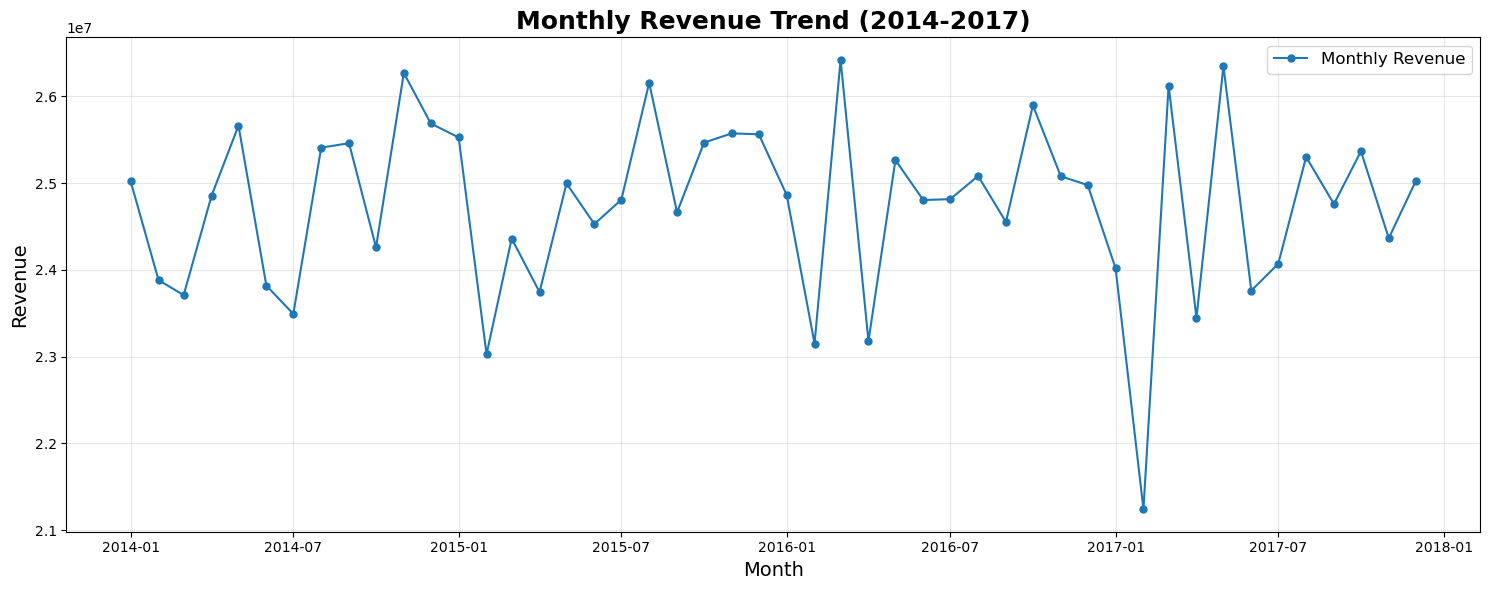

In [48]:
# Monthly revenue
monthly_sales = (
    df_new.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)

# Create Year-Month column
monthly_sales['date'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month'].astype(str) + '-01'
)

monthly_sales = monthly_sales.sort_values('date')

# Plot
plt.figure(figsize=(15, 6))

# Actual monthly revenue with bullet points
plt.plot(
    monthly_sales['date'],
    monthly_sales['revenue'],
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Monthly Revenue'
)

# Trend line

plt.title('Monthly Revenue Trend (2014-2017)', fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Revenue', fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

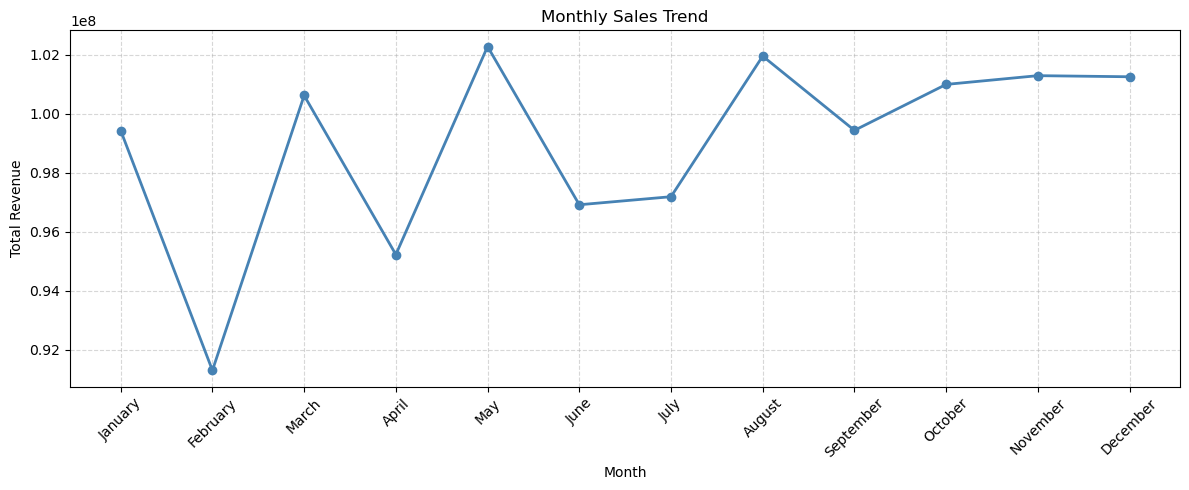

In [49]:
#Aggregation
monthly_trend = (
    df_new.groupby('month')['revenue']
    .sum()
    .reset_index()
)

#Month reindex
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_trend = monthly_trend.set_index('month').reindex(month_order).reset_index()

#Grapg Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend['month'], monthly_trend['revenue'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



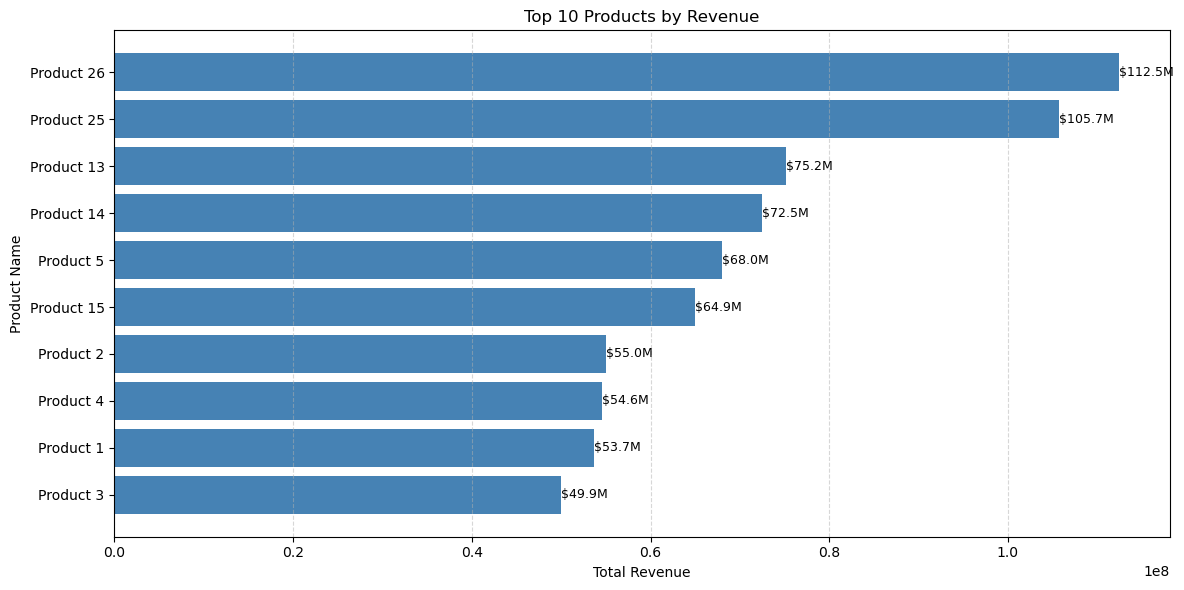

In [50]:
# Top 10 products by revenue
top10 = df_new.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10).reset_index()

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['product_name'], top10['revenue'], color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'${width/1e6:.1f}M',
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

<Figure size 12000x1000 with 0 Axes>

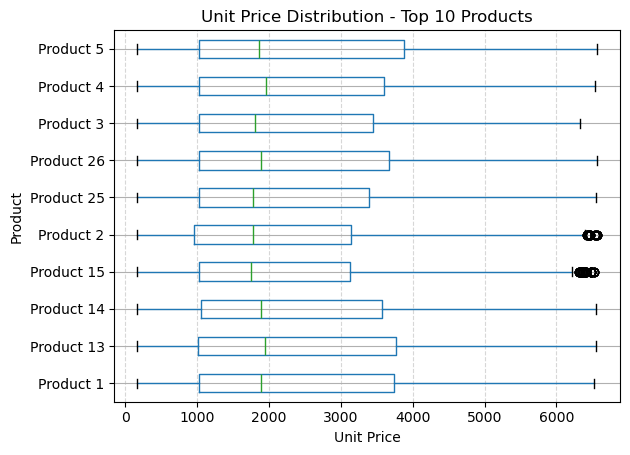

In [51]:
# Top 10 products by revenue
top10_products = df1.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10).index

# Filter only top 10
df_top10 = df1[df1['product_name'].isin(top10_products)]

# Plot
plt.figure(figsize=(120, 10))
df_top10.boxplot(column='unit_price', by='product_name', vert=False)
plt.title('Unit Price Distribution - Top 10 Products')
plt.suptitle('')
plt.xlabel('Unit Price')
plt.ylabel('Product')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [52]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


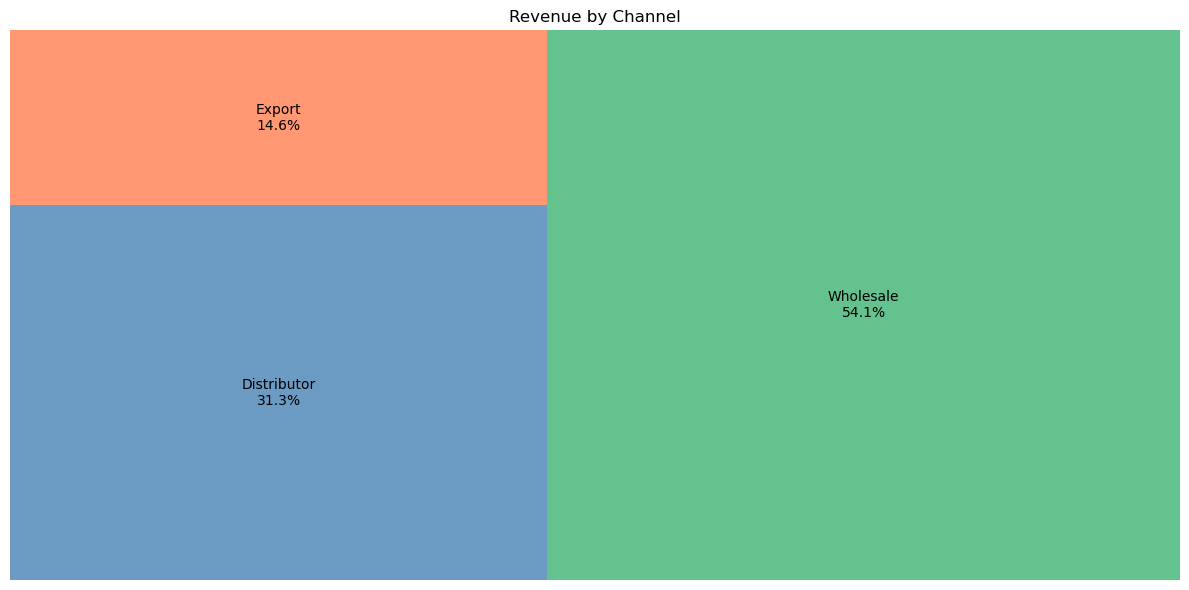

In [53]:
import squarify

# Aggregate revenue by channel
channel_revenue = df1.groupby('channel')['revenue'].sum().reset_index()

# Calculate percentage
channel_revenue['pct'] = (channel_revenue['revenue'] / channel_revenue['revenue'].sum() * 100)

# Plot
plt.figure(figsize=(12, 6))
squarify.plot(sizes=channel_revenue['revenue'],
              label=[f"{row['channel']}\n{row['pct']:.1f}%" 
                     for _, row in channel_revenue.iterrows()],
              color=['steelblue','coral','mediumseagreen','gold'],
              alpha=0.8)

plt.title('Revenue by Channel')
plt.axis('off')
plt.tight_layout()
plt.show()

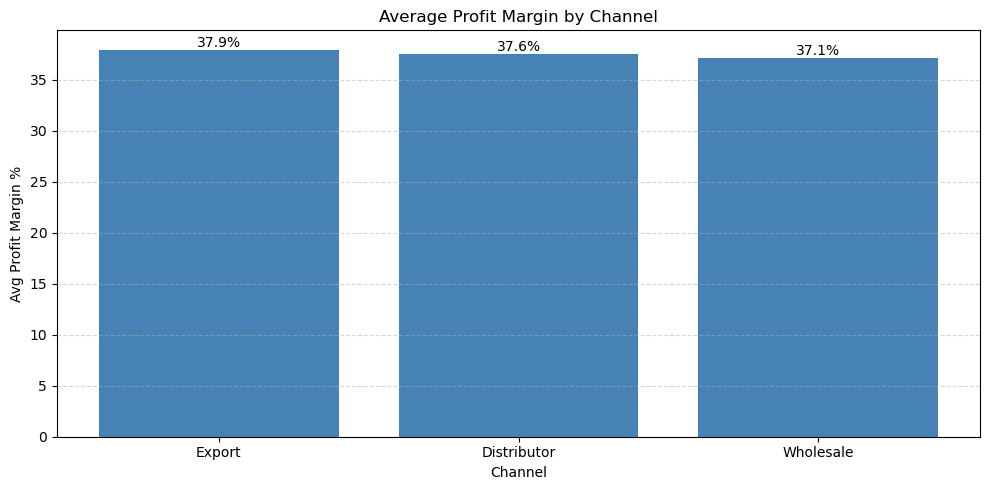

In [54]:
# Aggregate
channel_margin = df_new.groupby('channel')['profit_margin%'].mean().reset_index()
channel_margin = channel_margin.sort_values('profit_margin%', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(channel_margin['channel'], channel_margin['profit_margin%'], color='steelblue')
plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Avg Profit Margin %')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

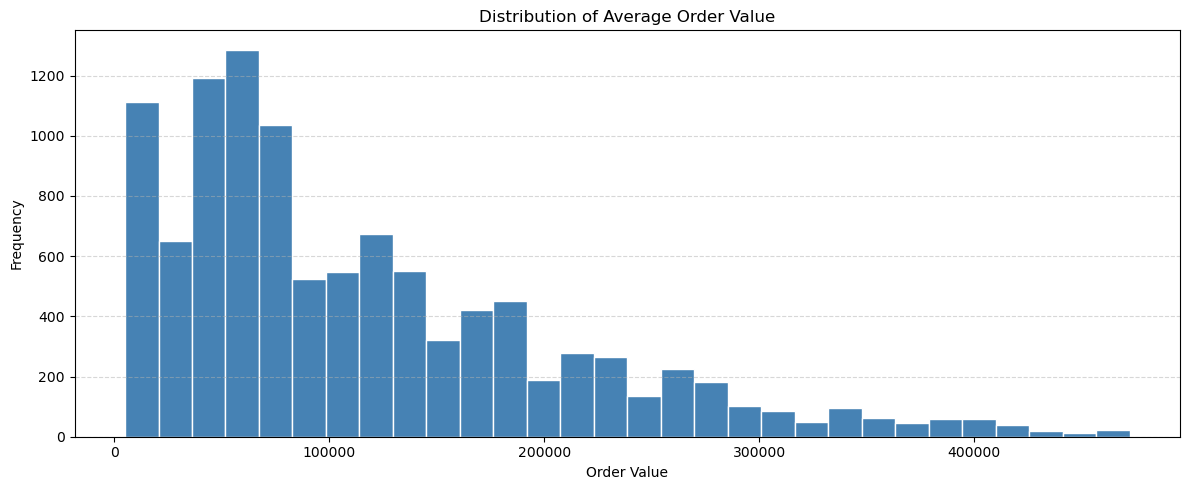

In [55]:
# Calculate AOV
aov = df1.groupby('order_number')['revenue'].sum()

# Plot
plt.figure(figsize=(12, 5))
plt.hist(aov, bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

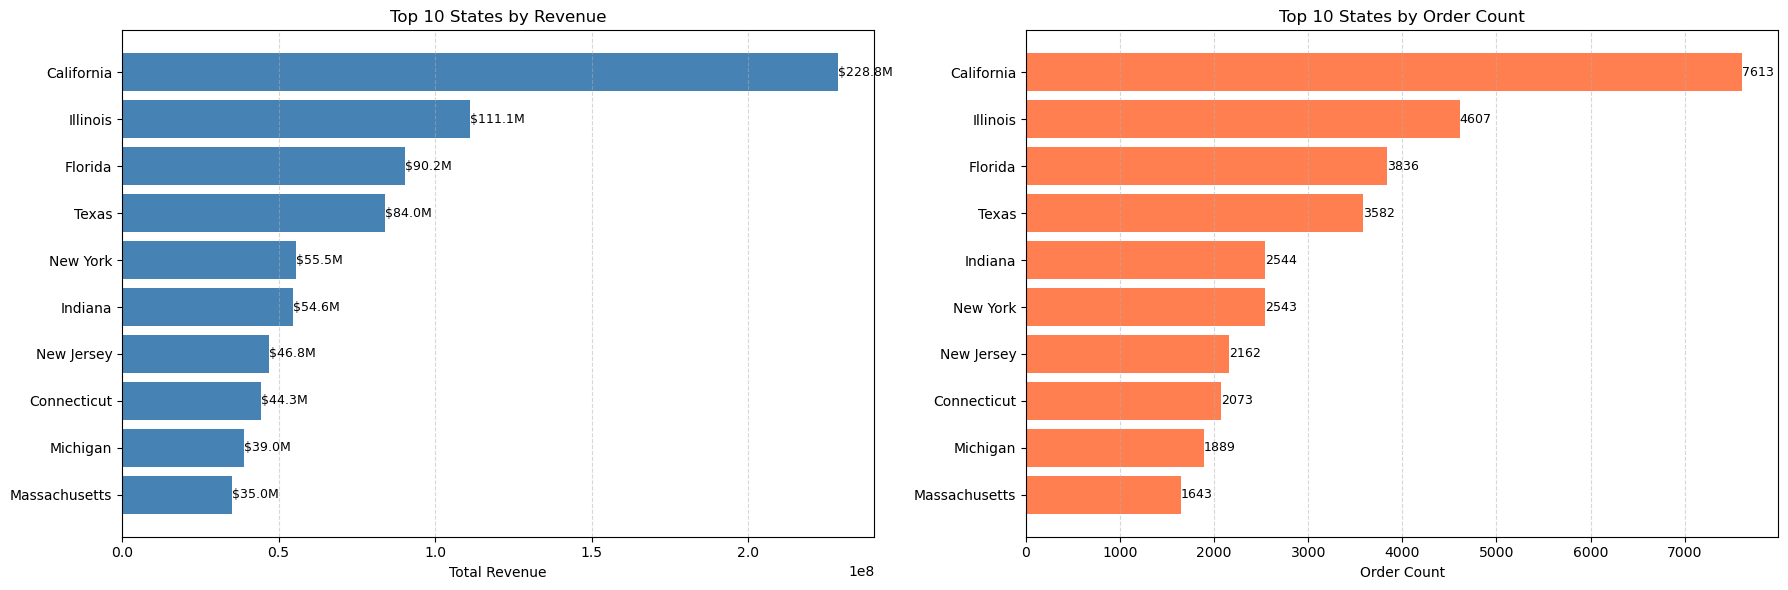

In [56]:
# Aggregate
state_data = df1.groupby('state_name').agg(
    revenue=('revenue', 'sum'),
    order_count=('order_number', 'nunique')
).reset_index()

# Top 10 by revenue
top10_revenue = state_data.sort_values('revenue', ascending=False).head(10)

# Top 10 by order count
top10_orders = state_data.sort_values('order_count', ascending=False).head(10)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Top 10 by Revenue ---
axes[0].barh(top10_revenue['state_name'], top10_revenue['revenue'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 States by Revenue')
axes[0].set_xlabel('Total Revenue')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in axes[0].patches:
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width()/1e6:.1f}M',
                 va='center', ha='left', fontsize=9)

# --- Top 10 by Order Count ---
axes[1].barh(top10_orders['state_name'], top10_orders['order_count'], color='coral')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 States by Order Count')
axes[1].set_xlabel('Order Count')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in axes[1].patches:
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}',
                 va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

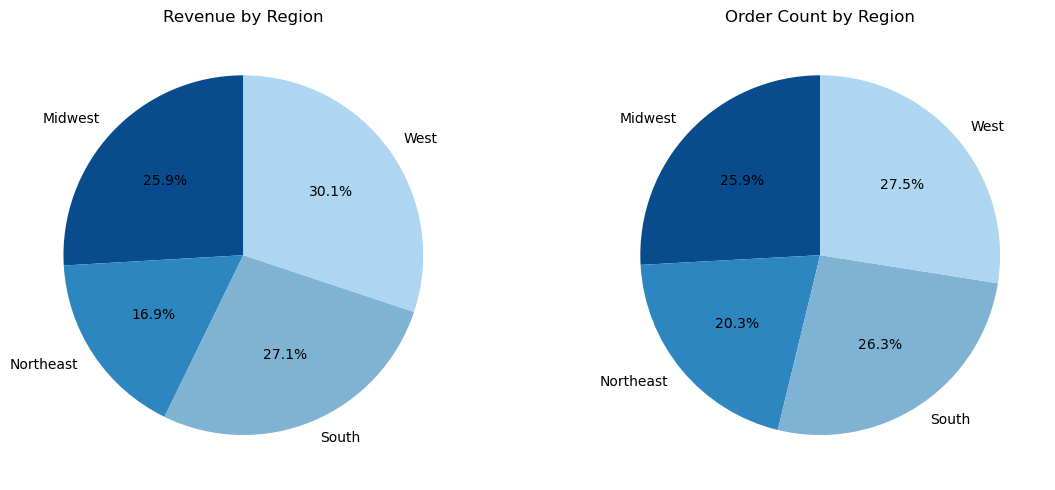

In [62]:
#Aggregate
region_data = df1.groupby('region').agg(
    revenue=('revenue', 'sum'),
    order_count=('order_number', 'nunique')
).reset_index()

colors = ['#084c8d', '#2e86c1', '#7fb3d3', '#aed6f1']

#Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Revenue by Region
axes[0].pie(region_data['revenue'], labels=region_data['region'],
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Revenue by Region')

#Order Count by Region
axes[1].pie(region_data['order_count'], labels=region_data['region'],
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Order Count by Region')

plt.tight_layout()
plt.show()

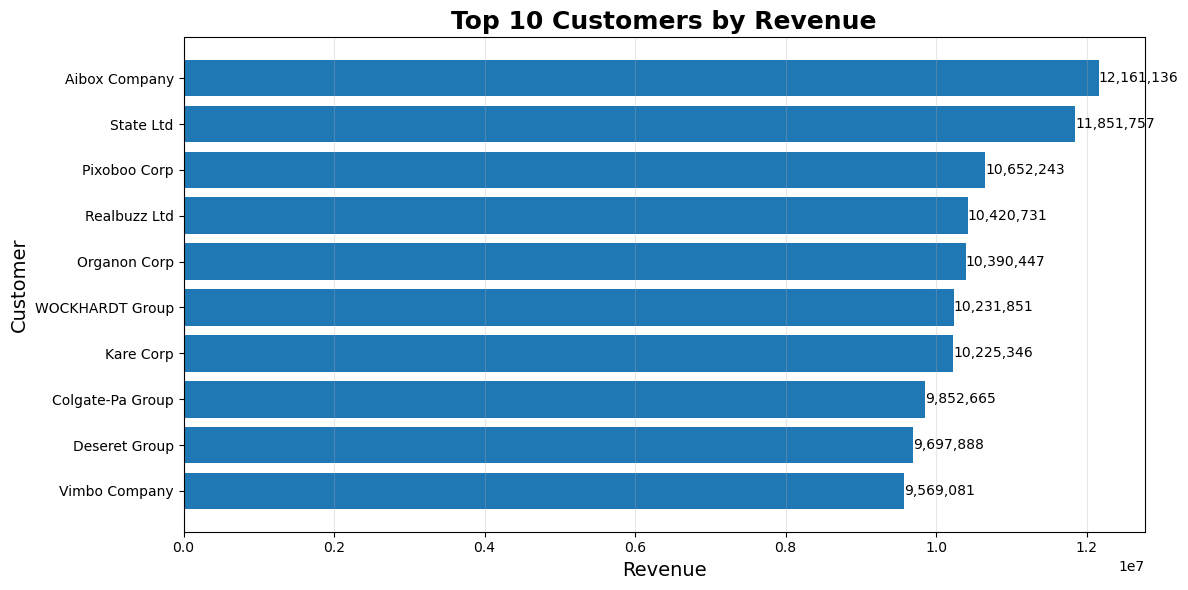

In [58]:
# Top 10 customers by revenue
top_10_customers = (
    df_new.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))

plt.barh(
    top_10_customers['customer_name'],
    top_10_customers['revenue']
)

# Highest revenue at the top
plt.gca().invert_yaxis()

# Titles and labels
plt.title('Top 10 Customers by Revenue', fontsize=18, fontweight='bold')
plt.xlabel('Revenue', fontsize=14)
plt.ylabel('Customer', fontsize=14)

# Add revenue labels
for i, value in enumerate(top_10_customers['revenue']):
    plt.text(value, i, f'{value:,.0f}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.show()

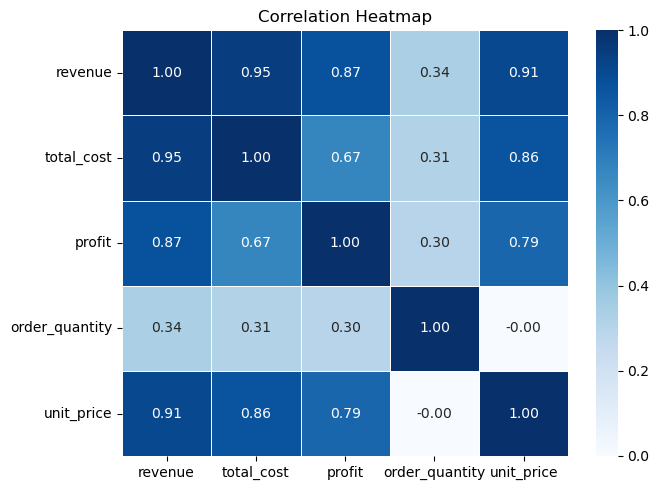

In [63]:
corr = df_new[['revenue', 'total_cost', 'profit', 'order_quantity', 'unit_price']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [65]:
df_new.to_csv('final.csv')

In [66]:
import sys
print(sys.executable)

C:\Users\Welcome\anaconda3\python.exe
